In [ ]:
# %%

import sympy as sy
from Tab0_constants import *
from Tab1_ion_pos_cal import *
from scipy import linalg
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, root, newton, minimize

[-8.86874334e-15 -1.19053887e-18  4.33731902e-11  3.36025162e-07]
12.658145257160133


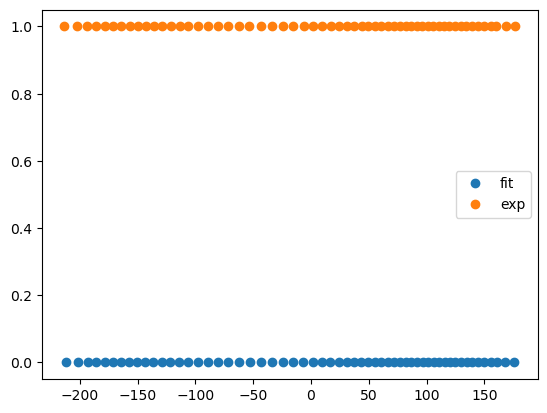

In [ ]:
# %%

# use ion position to fit the electrical potential
N_ions = 58
zpos_exp = np.array([-6.26566795747128, -5.59964251722938, -5.10147810288158, -4.6277053969431705, -4.185189732649032, -3.744033689546192, -3.3346501178786743, -2.9203828151329665, -2.492515029013504, -2.083273354578818, -1.6663694612070294, -1.233255673032396, -0.8029583902207562, -0.3525933480852453, 0.09898978961325867, 0.5740326866630566, 1.0898932142133968, 1.6045475748084679, 2.1309710340988945, 2.683541972785637, 3.2403313412909784, 3.828815195107811, 4.402553981635625, 4.952196583755355, 5.494925567942459, 6.016970938790197, 6.5044017304015345, 6.980987379317148, 7.427426060016152, 7.854072219268418, 8.243930408247182, 8.628663126710592, 8.992453388018394, 9.347716362499249, 9.691605543874855, 10.018581729639465, 10.353964909576721, 10.66314621250206, 10.962749553063073, 11.26548247504936, 11.550151422065454, 11.830079931683219, 12.120406233136853, 12.410817847802484, 12.668406250099718, 12.974022178526688, 13.252140348823405, 13.491299130895507, 13.80971170371858, 14.082166457469997, 14.350029705149309, 14.654832186717083, 14.978997267672954, 15.29117706777991, 15.62622779154524, 15.921664410449951, 16.437421115734054, 16.890433717688552])/38*640*1e-6
zpos_exp= zpos_exp-np.mean(zpos_exp)

result = minimize(Loss_function_position, 
                  x0=np.array([-7.66734435e-15, -1.00000000e-18,  3.52488470e-11,  2.93564624e-07]),            # initial value
                  args=(N_ions, zpos_exp), tol=1e-30, method='Nelder-Mead',
                  bounds=((-1e-12, 1e-12), (-1e-17, 1e-17), (-1e-10, 1e-10), (-1e-3, 1e-3)))  # bound value

print(result.x)

zpos = equ_pos_fast(N_ions, *result.x)  # calculate ion's position
# result.x = np.array([-1/2 * mca * (2*np.pi*0.1*1e6)**2,0, 0, 5e-7])
zpos = equ_pos_fast(N_ions, *result.x)
plt.plot(zpos*1e6,np.zeros(N_ions), "o", label="fit")
plt.plot(zpos_exp*1e6,np.ones(N_ions), "o", label="exp")
print(Loss_function_position(result.x, N_ions, zpos_exp))
plt.legend()
plt.show()

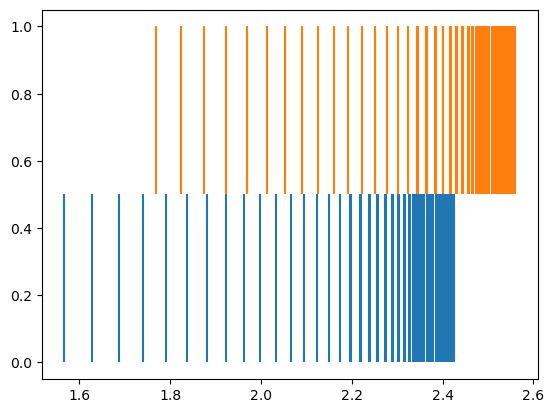

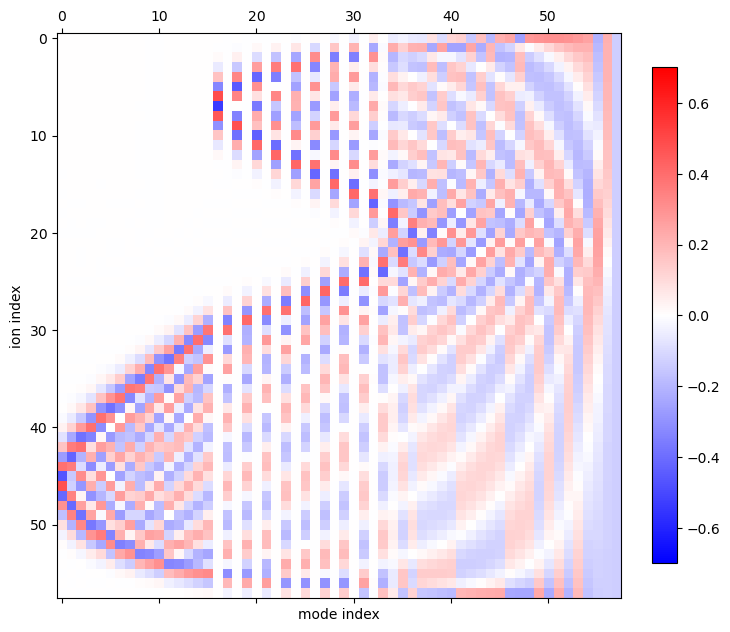

In [ ]:
# %%

# calculate x and y frequency and mode pattern
omega_y = 2*np.pi * 2.56 * MHz
yfreq_cal, ymode, _ = radial_mode_spectrum(N_ions, omega_y, zpos)
omega_x = 2*np.pi * 2.425 * MHz
xfreq_cal, xmode, _ = radial_mode_spectrum(N_ions, omega_x, zpos)
plt.vlines(xfreq_cal/ (2 * np.pi * MHz), 0, 0.5, "C0")
plt.vlines(yfreq_cal/ (2 * np.pi * MHz), 0.5, 1, "C1")
plt.show()
# plot ion's axial mode amplitude b(m, i) for each ion, m is motional index, i is ion's index
fig, ax = plt.subplots(figsize=(8, 8))
pcm = plt.matshow(xmode, fignum=0, cmap='bwr', vmax=0.7, vmin=-0.7)
plt.xlabel('mode index')
plt.ylabel('ion index')
fig.colorbar(pcm, fraction=0.04)
plt.show()

(2.2, 2.4)

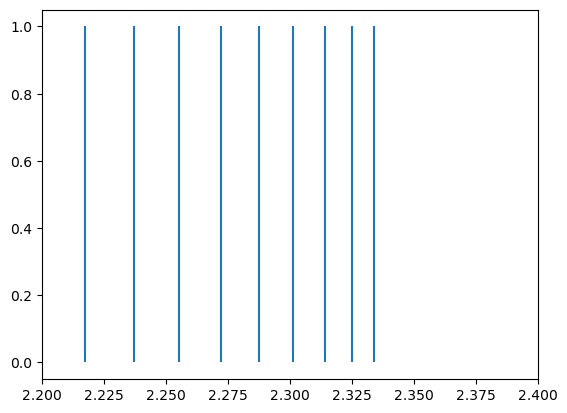

In [ ]:
# %%

ionlist = [6, 7, 8, 9, 10]
modelist = []
for ii in range(N_ions):
   flag = 0
   for jj in ionlist:
      if np.abs(ymode[jj][ii]) > 0.05 and flag < 1:
         modelist.append(ii)
         flag += 1
      else:
         continue

plt.vlines([xfreq_cal[int(ii)] / (2 * np.pi * MHz) for ii in modelist[:10]], 0, 1, "C0")
# plt.vlines([yfreq_cal[int(ii)] / (2 * np.pi * MHz) for ii in modelist[:5]], 0, 1, "C1")
plt.xlim(2.2, 2.4)

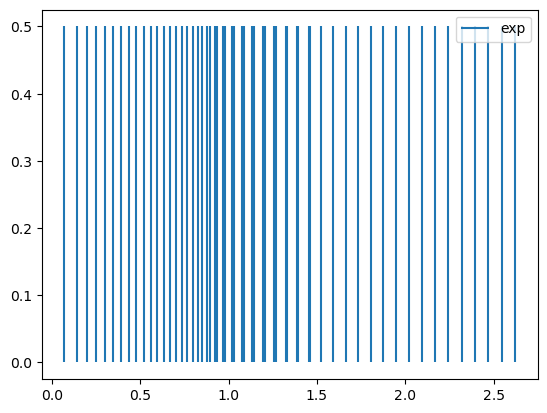

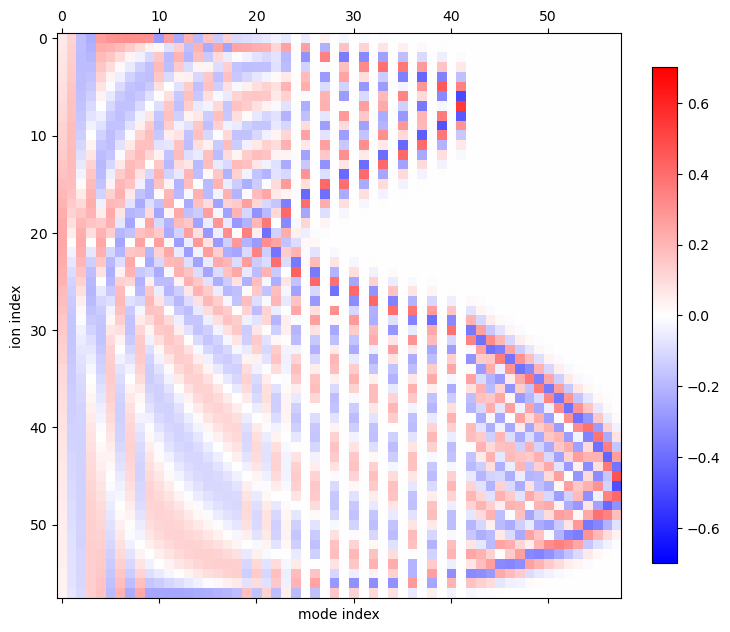

In [ ]:
# %%

# plot axial mode frequency and pattern
zfreq_cal, zmode, _ = axial_mode_spectrum(N_ions, zpos, *result.x) # calculate ion's axial frequency
plt.vlines(zfreq_cal/ (2 * np.pi * MHz), 0, 0.5, "C0", label='exp')
plt.legend()
plt.show()
# plot ion's axial mode amplitude b(m, i) for each ion, m is motional index, i is ion's index
fig, ax = plt.subplots(figsize=(8, 8))
pcm = plt.matshow(zmode, fignum=0, cmap='bwr', vmax=0.7, vmin=-0.7)
plt.xlabel('mode index')
plt.ylabel('ion index')
fig.colorbar(pcm, fraction=0.04)

In [ ]:
# %%

# calculate axial position
zd = []
for ii in range(N_ions-1):
    zd.append((zpos[ii+1] - zpos[ii])*1e6)
print(zd)

[9.943391633270704, 8.401457639462949, 7.689871549464015, 7.297270967481656, 7.073155519666607, 6.95507688367925, 6.912305927800295, 6.928226249395072, 6.993412704703751, 7.102434299785656, 7.252137193721218, 7.44052300182701, 7.665789578566946, 7.925258568232746, 8.213976176368835, 8.52285506927916, 8.836461370774018, 9.131115457319273, 9.37490514301239, 9.531878189303992, 9.571440294438265, 9.479756515617073, 9.26593882956475, 8.95812378765986, 8.592442769316188, 8.20237239821943, 7.813113782843261, 7.4408020337130285, 7.094228138441566, 6.777138019081088, 6.490186368365863, 6.232319019801343, 6.001655361087324, 5.7960134157765975, 5.613204308385377, 5.451186887263239, 5.308141583315978, 5.18249998278398, 5.0729520159385295, 4.978443795972782, 4.8981740124692354, 4.831594044743702, 4.778415800610849, 4.738631304114447, 4.7125491873280785, 4.700855779357391, 4.704713245039922, 4.725915987896027, 4.767143124937605, 4.83237783372039, 4.927634244362408, 5.062292589947374, 5.2517478828085

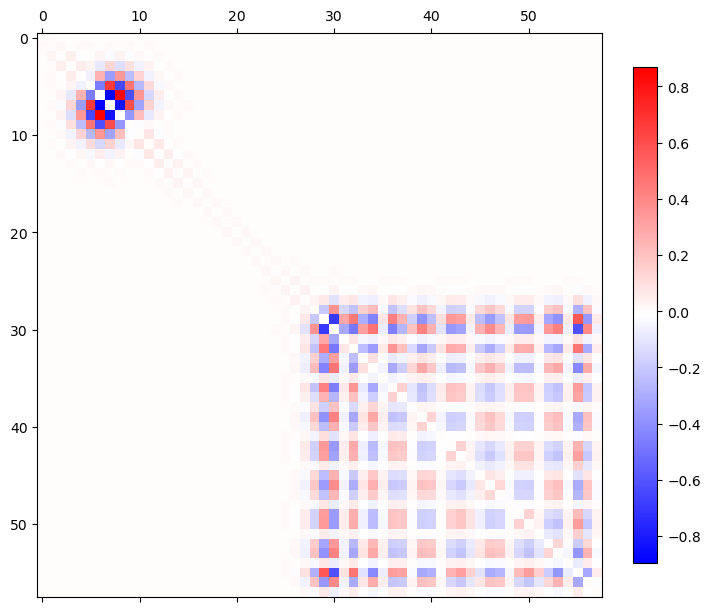

In [ ]:
# %%

# calculate ion coupling
laser_freq = (2 * np.pi * MHz) * 2.2

J_matrix = np.zeros((N_ions, N_ions))
Omega = 2 * np.pi * MHz * 0.1
tau = 200 * us
for ii in range(N_ions):
    for jj in range(N_ions):
        J_matrix[ii][jj] = Jij([ii, jj], laser_freq - xfreq_cal, xmode)


fig, ax = plt.subplots(figsize=(8, 8))
pcm=plt.matshow(J_matrix * Omega**2/2*0.05**2/(2*np.pi*MHz)*1e3, fignum=0, cmap='bwr')
fig.colorbar(pcm, fraction=0.04)
plt.show()